# EDA — UNSW-NB15

**Dataset:** UNSW-NB15 — Network Attack Detection  
**Objetivo:** Entender las 36 features de red, el desbalance de clases, y definir qué features usar para el Modelo B.  
**Archivos:** `data/raw/unsw_nb15/UNSW_NB15_training-set.parquet` y `UNSW_NB15_testing-set.parquet`

Ver `docs/eda.md` para el plan completo.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

TRAIN_PATH = '../../data/raw/unsw_nb15/UNSW_NB15_training-set.parquet'
TEST_PATH  = '../../data/raw/unsw_nb15/UNSW_NB15_testing-set.parquet'

## 1. Carga y estructura básica

In [2]:
train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head(3)

Train shape: (175341, 36)
Test shape:  (82332, 36)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,Normal,0


In [3]:
print('Dtypes:')
print(train.dtypes)

Dtypes:
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is

## 2. El label

In [4]:
print('Label — valores únicos:', train['label'].unique())
print('Dtype:', train['label'].dtype)
print()
print('Train:')
print(train['label'].value_counts())
print()
print('Test:')
print(test['label'].value_counts())

Label — valores únicos: [0 1]
Dtype: int8

Train:
label
1    119341
0     56000
Name: count, dtype: int64

Test:
label
1    45332
0    37000
Name: count, dtype: int64


## 3. Distribución de clases

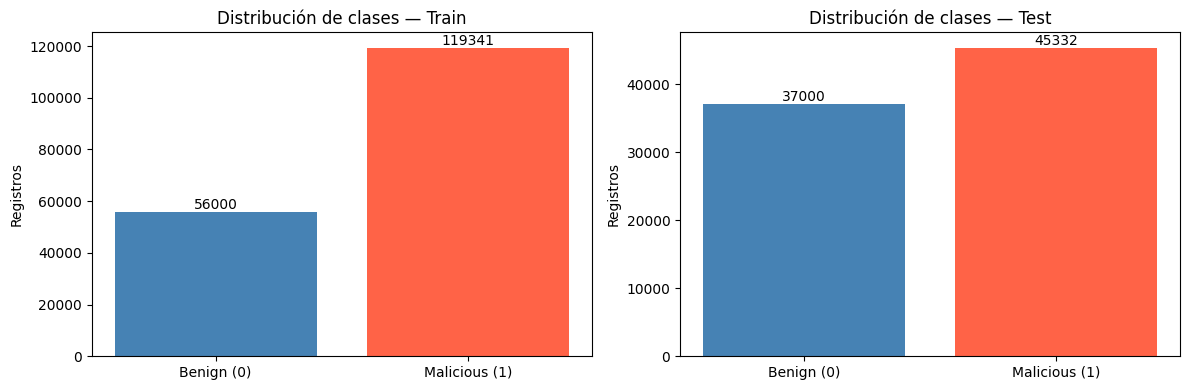

Train: Benign=56000 (31.9%)  Malicious=119341 (68.1%)
Test: Benign=37000 (44.9%)  Malicious=45332 (55.1%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(['Benign (0)', 'Malicious (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.bar_label(bars, fmt='%d')
    ax.set_title(f'Distribución de clases — {title}')
    ax.set_ylabel('Registros')

plt.tight_layout()
plt.show()

for df, name in [(train, 'Train'), (test, 'Test')]:
    counts = df['label'].value_counts().sort_index()
    print(f'{name}: Benign={counts[0]} ({counts[0]/len(df)*100:.1f}%)  Malicious={counts[1]} ({counts[1]/len(df)*100:.1f}%)')

## 4. Categorías de ataque (attack_cat)

Categorías de ataque (train):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


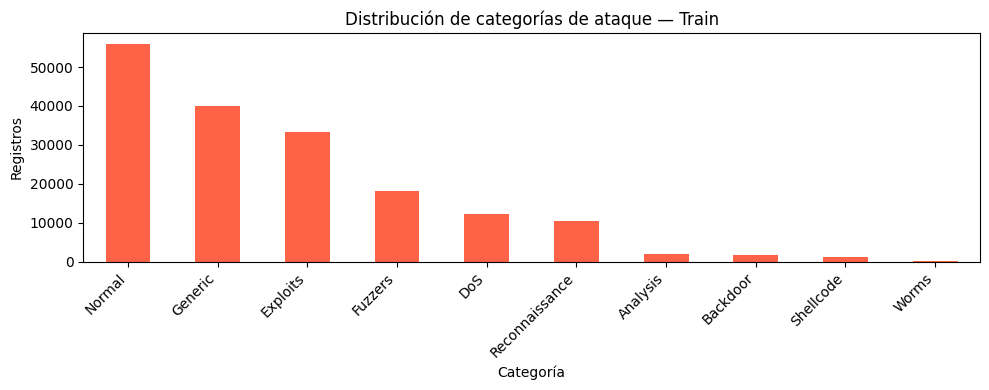

In [6]:
print('Categorías de ataque (train):')
print(train['attack_cat'].value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
train['attack_cat'].value_counts().plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Distribución de categorías de ataque — Train')
ax.set_xlabel('Categoría')
ax.set_ylabel('Registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Nulos por columna

In [7]:
nulls = train.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(train) * 100).round(2)
result = pd.DataFrame({'nulos': nulls, 'pct': nulls_pct})
print('Columnas con nulos:')
print(result[nulls > 0])
print()
print('Columnas sin nulos:', (nulls == 0).sum())

Columnas con nulos:
Empty DataFrame
Columns: [nulos, pct]
Index: []

Columnas sin nulos: 36


## 6. Features categóricas

In [9]:
cat_cols = train.select_dtypes(include='category').columns.drop('attack_cat').tolist()
print('Columnas categóricas:', cat_cols)
print()
for col in cat_cols:
    print(f'{col} — {train[col].nunique()} valores únicos:')
    print(train[col].value_counts().head(10))
    print()

Columnas categóricas: ['proto', 'service', 'state']

proto — 133 valores únicos:
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
swipe       201
Name: count, dtype: int64

service — 13 valores únicos:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

state — 9 valores únicos:
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64



## 7. Features numéricas — estadísticas descriptivas

In [10]:
num_cols = train.select_dtypes(include=[np.number]).columns.drop('label').tolist()
print(f'Features numéricas: {len(num_cols)}')
train[num_cols].describe().T.round(2)

Features numéricas: 31


,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.360000e+00,6.480000e+00,0.0,0.00,0.00,6.700000e-01,6.000000e+01
spkts,175341.0,2.030000e+01,1.368900e+02,1.0,2.00,2.00,1.200000e+01,9.616000e+03
dpkts,175341.0,1.897000e+01,1.102600e+02,0.0,0.00,2.00,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844840e+03,1.747656e+05,28.0,114.00,430.00,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.00,164.00,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654010e+05,0.0,32.79,3225.81,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.34,879674.75,8.888889e+07,5.988000e+09
dload,175341.0,6.712056e+05,2.421312e+06,0.0,0.00,1447.02,2.784487e+04,2.242273e+07
sloss,175341.0,4.950000e+00,6.601000e+01,0.0,0.00,0.00,3.000000e+00,4.803000e+03
dloss,175341.0,6.950000e+00,5.273000e+01,0.0,0.00,0.00,2.000000e+00,5.484000e+03


## 8. Outliers en features de flujo clave

/var/folders/pq/bc_dm1vj7ddfy82mn6pcb_5c0000gn/T/ipykernel_56339/3914579017.py:8: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=40, alpha=0.5, color=color, label=str(lbl))


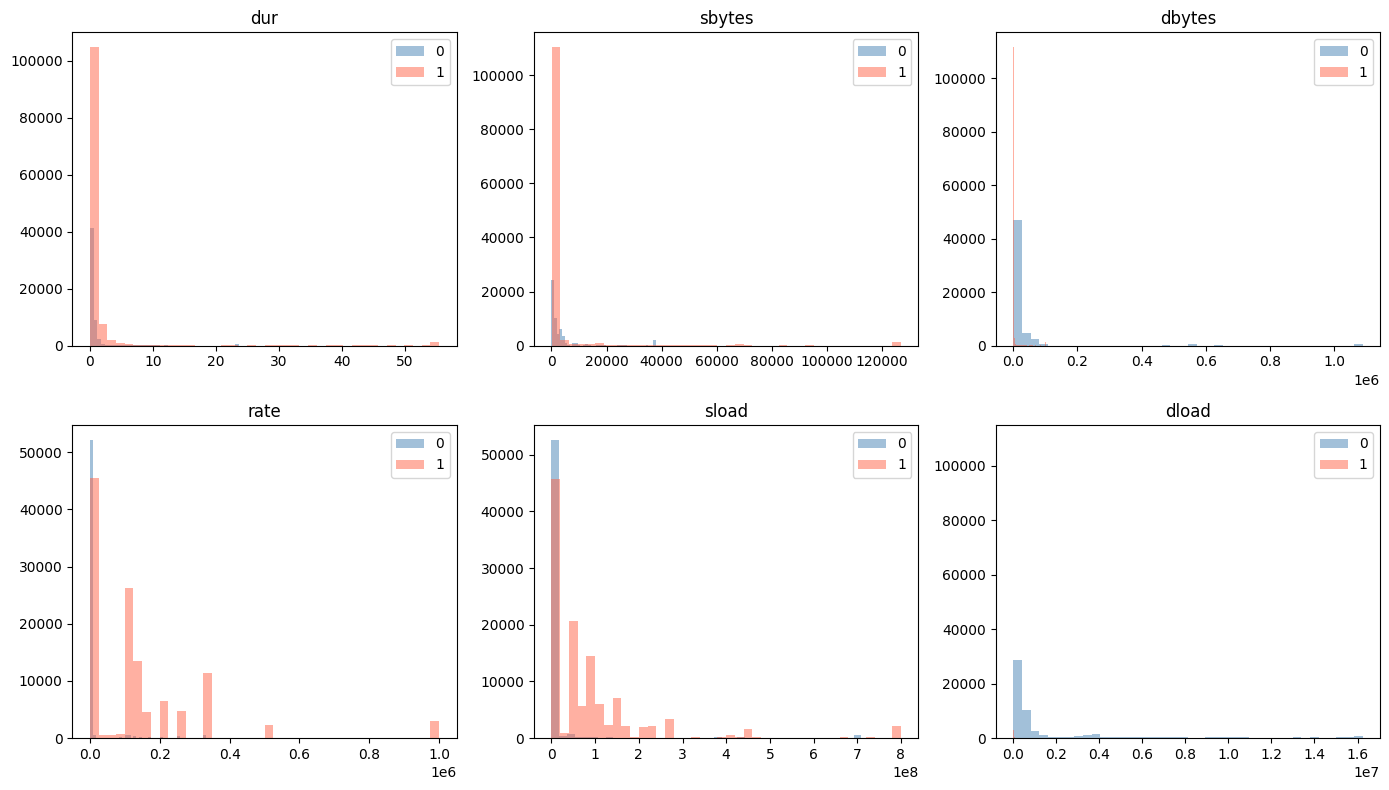

In [11]:
flow_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload']
flow_features = [f for f in flow_features if f in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), flow_features):
    for lbl, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = train[train['label'] == lbl][col]
        ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=40, alpha=0.5, color=color, label=str(lbl))
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Correlación entre features numéricas

In [12]:
corr_matrix = train[num_cols + ['label']].corr()

# Correlación con el label
corr_label = corr_matrix['label'].drop('label').sort_values(ascending=False)
print('Top 15 features — correlación con label:')
print(corr_label.head(15).round(3))
print()
print('Bottom 5 features — menor correlación:')
print(corr_label.tail(5).round(3))

Top 15 features — correlación con label:
ct_dst_sport_ltm    0.357
rate                0.338
ct_src_dport_ltm    0.306
sload               0.183
ackdat              0.097
tcprtt              0.082
synack              0.058
dur                 0.036
sbytes              0.019
ct_flw_http_mthd    0.016
trans_depth         0.011
sloss              -0.001
sjit               -0.007
smean              -0.011
ct_ftp_cmd         -0.011
Name: label, dtype: float64

Bottom 5 features — menor correlación:
stcpb   -0.255
dwin    -0.320
swin    -0.334
dmean   -0.342
dload   -0.394
Name: label, dtype: float64


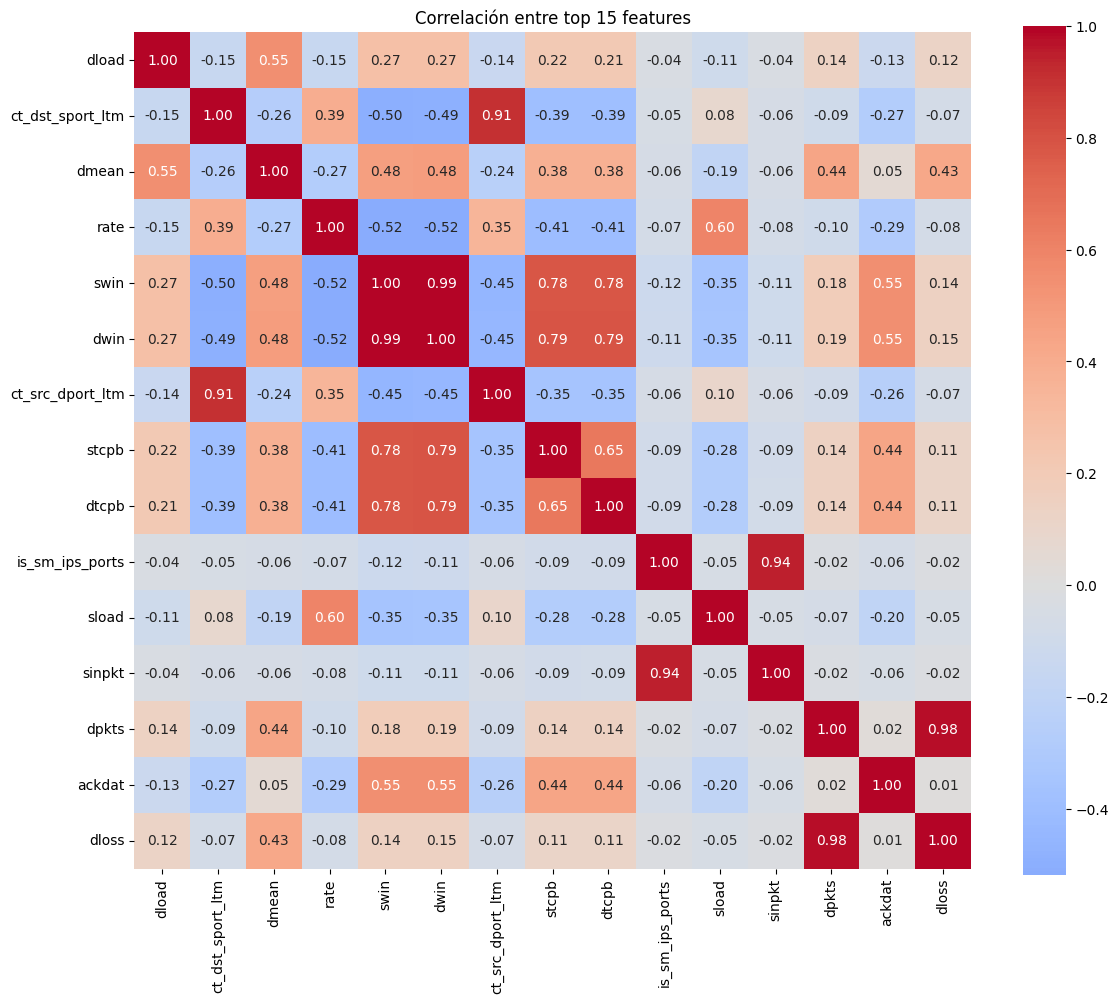

In [13]:
# Heatmap de correlación entre features (detectar redundancias)
top_features = corr_label.abs().sort_values(ascending=False).head(15).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    train[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    ax=ax, square=True
)
ax.set_title('Correlación entre top 15 features')
plt.tight_layout()
plt.show()

## 10. Features constantes o de baja varianza

In [14]:
uniqueness = train[num_cols].nunique().sort_values()
print('Features numéricas con pocos valores únicos (candidatas a descartar):')
print(uniqueness[uniqueness < 10])

Features numéricas con pocos valores únicos (candidatas a descartar):
is_sm_ips_ports    2
ct_ftp_cmd         4
is_ftp_login       4
dwin               7
dtype: int64


## 11. Observaciones clave

### Hallazgos principales

- **Label:** `int8` con valores `[0, 1]` en train y test ✅ — listo, sin transformación
- **Distribución de clases:** Train 68.1% malicious / Test 55.1% — split predefinido en parquet, no modificar
- **Categorías de ataque:** Generic (33.5%) + Exploits (28%) + Fuzzers (15.2%) = 76.7% del total
- **Nulos:** ninguno — las 36 columnas están completas ✅
- **Protocolo `proto`:** 133 valores únicos → estrategia top-10 + `other`
- **Outliers extremos:** `sbytes` (max 12M), `sload` (max 5.9B), `rate` (max 1M) → RobustScaler
- **Features más correlacionadas con label:** `dload` (-0.394), `dmean` (-0.342), `swin` (-0.334), `ct_dst_sport_ltm` (0.357), `rate` (0.338)
- **Features redundantes:** `swin`/`dwin` (0.99), `dpkts`/`dloss` (0.98), `is_sm_ips_ports`/`sinpkt` (0.94)
- **`is_ftp_login`:** anomalía — 4 valores únicos cuando debería ser binaria

### Decisiones de preprocessing

| Aspecto | Decisión |
|---|---|
| Normalización | `RobustScaler` — outliers extremos |
| `proto` encoding | Top-10 + `other` → one-hot |
| `service` / `state` encoding | One-hot directo |
| Features descartadas | `dwin`, `dloss`, `is_sm_ips_ports` |
| Features a monitorear | `stcpb`, `dtcpb`, `is_ftp_login` |
| Desbalance | `class_weight='balanced'` como primera estrategia |
